 **The Capital Asset Pricing Model (CAPM):**
 
 $$
 \mathbb{E}[R_i] = r_f + \beta_i \big(\mathbb{E}[R_m] - r_f\big)
 $$
 
 - $\mathbb{E}[R_i]$ : Expected return of asset $i$
 - $r_f$ : Risk-free rate   
 - $\beta_i$ : Sensitivity (“beta”) of $i$ to market returns
 - $\mathbb{E}[R_m]$ : Expected market return
 - $\big(\mathbb{E}[R_m] - r_f\big)$ : Market risk premium
 
Reference: Sharpe, W.F. (1964). "Capital Asset Prices: A Theory of Market Equilibrium under Conditions of Risk." Journal of Finance.

 
The standard CAPM model (above) has no "alpha" term—CAPM assumes the market is efficient, so on average, all assets plot exactly on the line: 
 
$$\mathbb{E}[R_i] = r_f + \beta_i (\mathbb{E}[R_m] - r_f)$$
 
In real data, we often observe persistent deviations from this line. 
 
We capture these deviations with an **"alpha"** term by amending the regression equation:

$$
 R_i = \alpha_i + r_f + \beta_i (R_m - r_f) + \varepsilon
$$
 
Here, $\alpha_i$ (alpha) measures the excess return of asset $i$ beyond what is predicted by beta and the market, after adjusting for risk-free rate. 

If $\alpha>0$, the asset or portfolio is "beating CAPM"; if $\alpha<0$, it's underperforming.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import matplotlib.ticker as mtick
import statsmodels.api as sm
from scipy import stats
import pandas_datareader as pdr

### **Setting Parameters** [IMPORTANT] ###

In [3]:
monthly = True # set "monthly = false" if we're using daily returns.
# This will change the ENTIRE output of the program so use carefully.

start_date = ""  #Date format: yyyy-mm-dd
end_date = ""  #leave these blank ("") if no specific start / end date

ticker = "^RUT" #Benchmark Ticker (Yahoo Finance)

rate_ticker = 'TB1YR' #Yield Ticker (FRED) -- Risk Free Rate Proxy
# Important: DTB1YR = daily || TB1YR = monthly

fund_data_path = "M:/_Intern Folder/Matthew/Parkman Data Analysis Project/PHP_Fund_Returns_Monthly.xlsx" # Must be in .xlsx format
# Must have only 2 columns called Date and Return (in decimals)

### Data Pulling & Cleaning ###

In [4]:
# Pull historical data from yfinance starting from the year 2000
market_data = yf.download(ticker, start="2000-01-01", auto_adjust=True, multi_level_index=False) 
market_data['market_rets'] = market_data['Close'].pct_change()
market_data = market_data.dropna()
market_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume,market_rets
Date,,,,,,
2000-01-04,478.380005,497.049988,478.200012,497.049988,1009000000,-0.036340
2000-01-05,478.829987,479.480011,467.559998,478.380005,1085500000,0.000941
2000-01-06,475.339996,480.190002,474.399994,478.829987,1092300000,-0.007289
2000-01-07,488.309998,488.309998,475.339996,475.339996,1225200000,0.027286
2000-01-10,501.890015,505.959991,488.309998,488.309998,1064800000,0.027810
...,...,...,...,...,...,...
2026-03-05,2585.570068,2621.649902,2560.989990,2619.310059,5989300000,-0.019135
2026-03-06,2525.300049,2554.659912,2518.310059,2554.659912,5793120000,-0.023310
2026-03-09,2553.669922,2559.169922,2463.379883,2503.189941,6709410000,0.011234


In [5]:
#Get fund returns data (depends on fund)
fund_data_path
fund_data = pd.read_excel(fund_data_path)  
fund_data = fund_data[['Date', 'Return']].dropna() 

# Prepare fund returns
fund_data['Date'] = pd.to_datetime(fund_data['Date'])
fund_data = fund_data.set_index('Date').sort_index()
# Returns must be in decimals (no percentages)

fund_data

,Return
Date,
2019-06-30,0.0085
2019-07-31,-0.0154
2019-08-31,-0.0289
2019-09-30,-0.0367
2019-10-31,0.0280
...,...
2025-09-30,0.0246
2025-10-31,0.0187
2025-11-30,0.0344


In [6]:
rf = pdr.get_data_fred(rate_ticker, start='2000-01-01')
rf = rf.rename(columns={rate_ticker: "Yield"})
rf.index.name = "Date"

rf['Yield'] = rf['Yield'].ffill() #forward fill on non trading days first

if monthly == True:
    # De-annualize it to monthly rate, change to decimal
    rf['Yield'] = ( (1 + rf['Yield'] / 100) ** (1/12) - 1 ) 
    rf = rf.resample('M').last() #resample daily rf to monthly (take last value of each month)
else: 
    # De-annualize it to daily rate, change to decimal
    rf['Yield'] = ( (1 + rf['Yield'] / 100) ** (1/252) - 1 ) 
rf

C:\Users\admin\AppData\Local\Temp\ipykernel_16508\2990652483.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  rf = rf.resample('M').last() #resample daily rf to monthly (take last value of each month)


,Yield
Date,
2000-01-31,0.004670
2000-02-29,0.004741
2000-03-31,0.004757
2000-04-30,0.004709
2000-05-31,0.004820
...,...
2025-10-31,0.002855
2025-11-30,0.002887
2025-12-31,0.002798


In [7]:
#get fund returns and market returns
fund_rets = fund_data['Return']

#Change this depending on the hedge fund returns data frequency
if monthly == True: 
    market_rets = market_data['market_rets'].resample('M').apply(lambda x: (1 + x).prod() - 1) #monthly returns

    # force all dates to the calendar month end -- comment if unused
    fund_rets.index = fund_rets.index.to_period('M').to_timestamp('M')
    market_rets.index = market_rets.index.to_period('M').to_timestamp('M')
    rf.index = rf.index.to_period('M').to_timestamp('M')
else: 
    market_rets = market_data['market_rets'] #daily returns

#SANITY CHECKS
market_rets.to_csv('market_returns_output.csv')
rf.to_csv('yield_output.csv')
fund_rets.to_csv('fund_returns_output.csv')

# Align series on common dates
df = pd.concat([fund_rets, market_rets, rf], axis=1, join='inner')
df.columns = ['Return', 'Market Return', 'Risk Free']

# Check if start / end date is specified
if start_date != "" and end_date != "":
    df = df.loc[start_date:end_date]
elif start_date != "" and end_date == "":
    df = df.loc[start_date:]
elif start_date == "" and end_date != "":
    df = df.loc[:end_date]

fund_data_concatenated = df.copy().drop(columns=['Market Return', 'Risk Free'])
fund_data_concatenated


C:\Users\admin\AppData\Local\Temp\ipykernel_16508\658539183.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  market_rets = market_data['market_rets'].resample('M').apply(lambda x: (1 + x).prod() - 1) #monthly returns


,Return
Date,
2019-06-30,0.0085
2019-07-31,-0.0154
2019-08-31,-0.0289
2019-09-30,-0.0367
2019-10-31,0.0280
...,...
2025-09-30,0.0246
2025-10-31,0.0187
2025-11-30,0.0344


In [8]:
removed = fund_data.reset_index().merge(fund_data_concatenated.reset_index(), how='left', indicator=True).query('_merge == "left_only"')
removed.set_index('Date')
removed

,Date,Return,_merge


### Finding CAPM Beta and Alpha + Testing statistical significance of Alpha ###

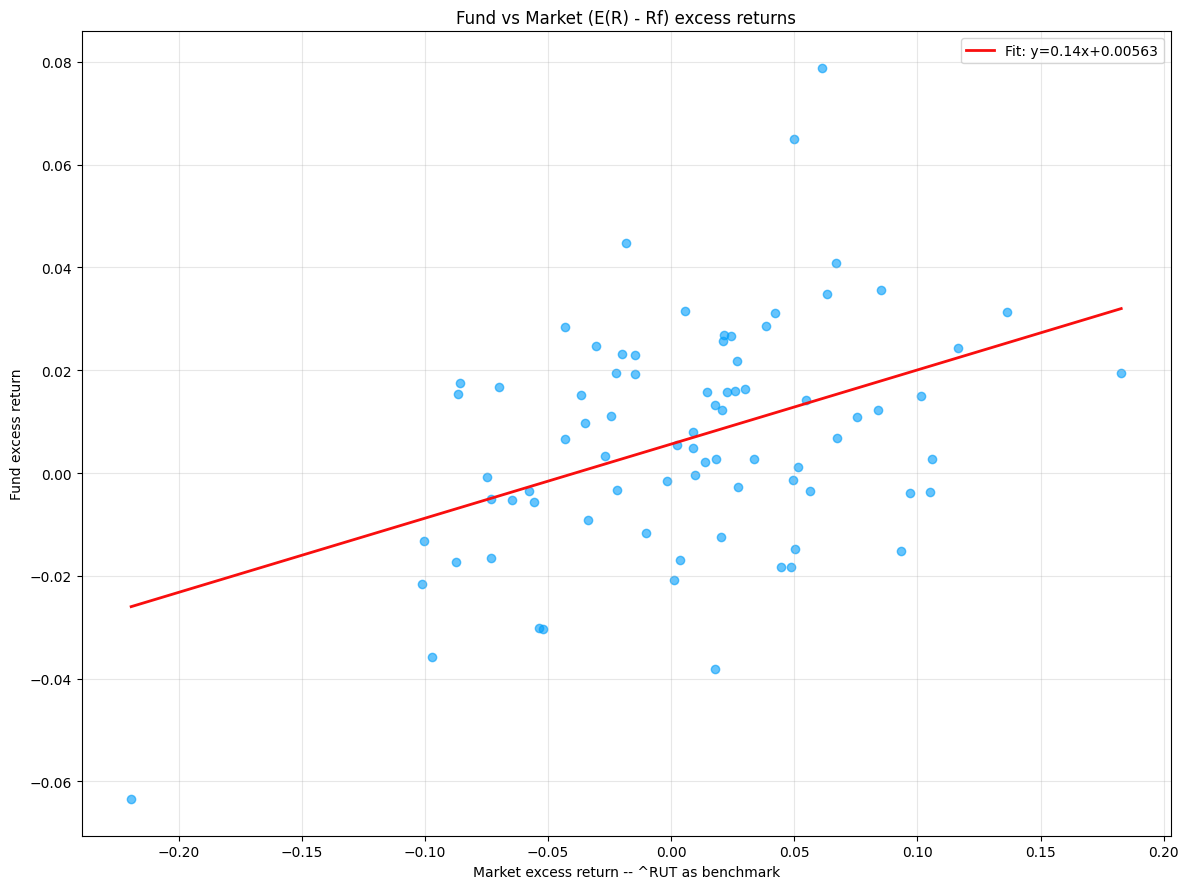

Alpha: 0.005632
Beta: 0.144286
R^2 = 0.175376
--------------------------------------------------
Condition: If p-value (one-tailed) < 0.10, alpha is present at the 10% SL.
--------------------------------------------------
The p-value of the CAPM intercept (0.00813) is statistically significant.
There is sufficient evidence to suggest that alpha exists.


In [9]:
alpha_color = "#f90e0eff"
beta_color = '#009efb'

df['Market Excess'] = df['Market Return'] - df['Risk Free']
df['Fund Excess'] = df['Return'] - df['Risk Free']

# CAPM regression on excess returns: fund_excess = alpha + beta * market_excess
# beta, alpha = np.polyfit(df['Market Excess'], df['Fund Excess'], 1)

y = df['Fund Excess']

x = sm.add_constant(df['Market Excess'])
results = sm.OLS(y, x).fit()
alpha = results.params['const']
beta = results.params['Market Excess']
p_value_alpha = results.pvalues['const'] / 2

# Scatter plot to display the fund's return corelation with market
x = df['Market Excess'].dropna() # x is a series
y = df['Fund Excess'].reindex(x.index).dropna()
x = x.reindex(y.index)

#find r squared for style points
y_hat = alpha + beta * x  
ss_res = ((y - y_hat) ** 2).sum()
ss_tot = ((y - y.mean()) ** 2).sum()
r2 = (ss_tot - ss_res) / ss_tot


# Fitted line: y = alpha + beta * x
x_sorted = x.sort_values()
y_fit = alpha + beta * x_sorted
plt.figure(figsize=(12, 9))
plt.scatter(x, y, alpha=0.6, color=beta_color)
plt.plot(
    x_sorted,
    y_fit,
    color=alpha_color,
    linewidth=2,
    label=f"Fit: y={beta:.2f}x+{alpha:.5f}",
)
plt.xlabel(f"Market excess return -- {ticker} as benchmark")
plt.ylabel("Fund excess return")
plt.title("Fund vs Market (E(R) - Rf) excess returns")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Alpha: {alpha:.6f}")
print(f"Beta: {beta:.6f}")
print(f"R^2 = {r2:.6f}")
print("-" *50)
print("Condition: If p-value (one-tailed) < 0.10, alpha is present at the 10% SL.")
print("-" *50)

if p_value_alpha < 0.1:
    print(f"The p-value of the CAPM intercept ({p_value_alpha:.5f}) is statistically significant.")
    print("There is sufficient evidence to suggest that alpha exists.")
else:
    print(f"The p-value of the CAPM intercept ({p_value_alpha:.5f}) is statistically insignificant.")
    print("There is insufficient evidence to suggest that alpha exists.")

## Investigating Alpha Decay using Time-Series analysis: Method #1 -- Exponential Decay ##

Paper: https://ink.library.smu.edu.sg/cgi/viewcontent.cgi?article=5734&context=lkcsb_research

"Have Capital Market Anomalies Attenuated in the Recent Era of High Liquidity and Trading Activity?" -- Section 4.3

Goal: Regress alpha data onto this curve: 

$$Y_t = a \cdot e^{bt + u_t}$$

Taking logs linearizes it: 

$$\ln(Y_t) = \ln(a) + b \cdot t + u $$

where $$Y_t = 1 + alpha_t$$

Null hypothesis: Anomalous profits (alpha) decrease exponentially over time.

Alternative hypothesis: Anomalous profits (alpha) don't decrease exponentially over time.

**Interpretation**: 

- If b < 0 and one-tailed p-value < 0.10, the strategy is experiencing statistically significant exponential decay in alpha.

- If b > 0 and one-tailed p-value < 0.10, the strategy is experiencing statistically significant exponential growth in alpha.

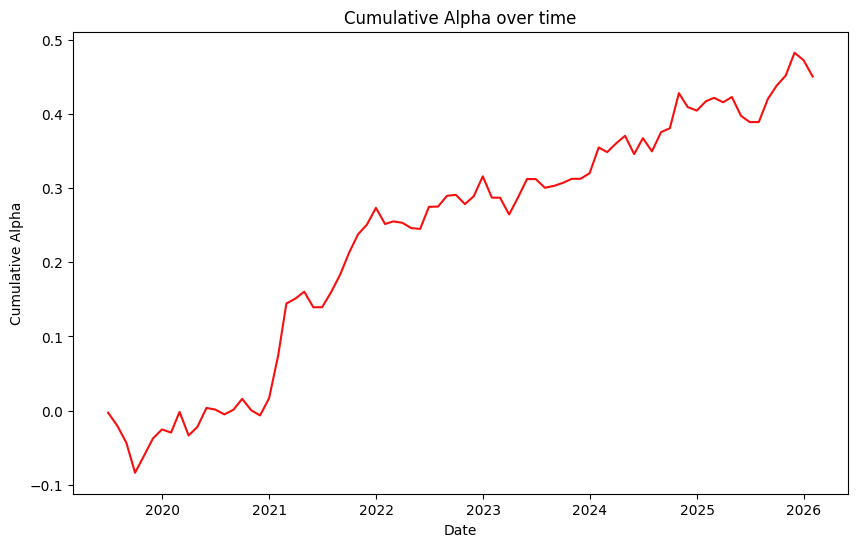

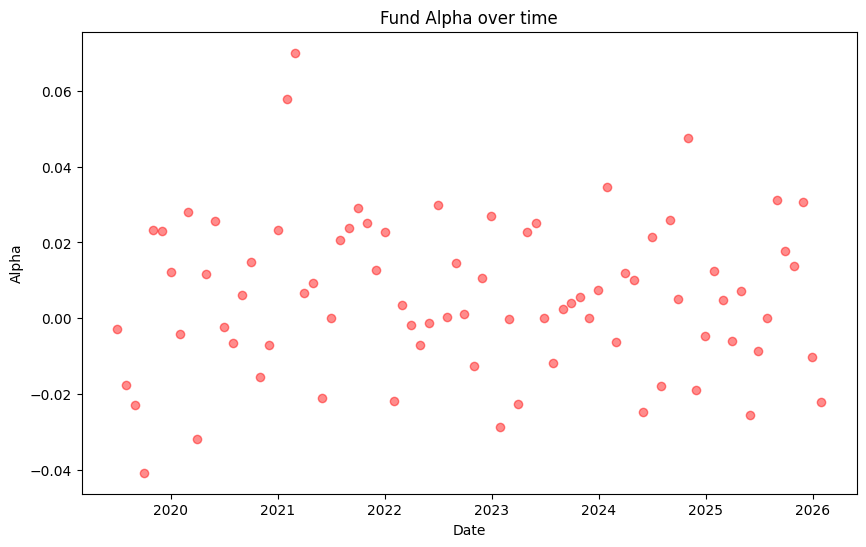

In [10]:
df['Alpha'] = df['Fund Excess'] - (df['Market Excess'] * beta)
df['Cumulative Alpha'] = df['Alpha'].cumsum()

fig, ax = plt.subplots(figsize=(10,6))
plt.title("Cumulative Alpha over time")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Alpha")
ax.plot(df.index, df['Cumulative Alpha'], color="#f90e0eff")

fig, ax = plt.subplots(figsize=(10,6))
plt.title("Fund Alpha over time")
ax.set_xlabel("Date")
ax.set_ylabel("Alpha")
plt.scatter(df.index, df['Alpha'], alpha=0.45, color="#ff0000ff")
df

df.to_csv("alpha_output.csv")

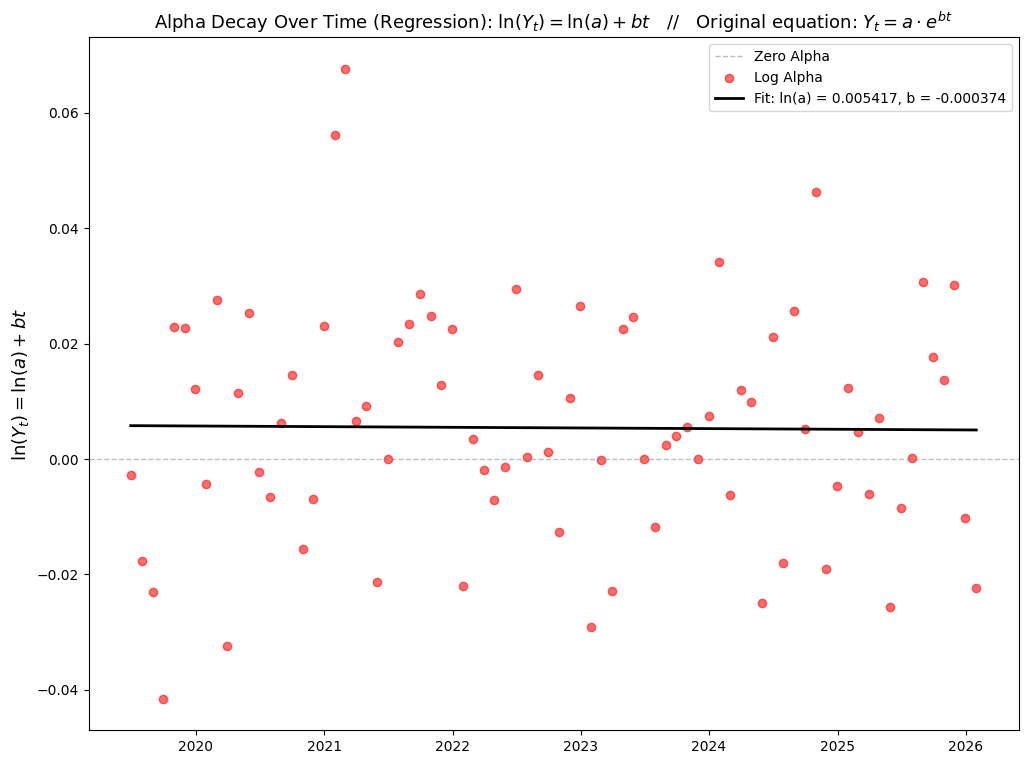

Note: This assumes that there exists a statistically significant alpha. If there is none, this decay result is pointless.
Condition: If p-value (one-tailed) < 0.10 and b < 0 (is negative), alpha decay is present at the 10% SL.
--------------------------------------------------
The p-value of the regression coefficient b (0.46156) is statistically insignificant.
There is insufficient evidence to suggest alpha decay.


In [11]:
df_alpha = df[['Alpha', 'Cumulative Alpha']].copy()
df_alpha['Log Alpha'] = np.log(1 + df_alpha['Alpha'])
df_alpha

array = np.linspace(-1, 1, len(df_alpha))
array = sm.add_constant(array)
model = sm.OLS(df_alpha['Log Alpha'], array)
results = model.fit()
# print(results.summary())

# ln_Yt = results.params['const'] + np.linspace(-1, 1, len(df_alpha)) * results.params['x1']
ln_Yt = results.fittedvalues
Y_t = np.exp(ln_Yt)

ln_a = results.params['const']
a = np.exp(ln_a)
b = results.params['x1']
p_decay_onetailed = results.pvalues['x1'] / 2

fig, ax = plt.subplots(figsize=(12,9))
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5, label="Zero Alpha")
plt.scatter(df_alpha.index, df_alpha['Log Alpha'], alpha=0.6, color="#f90e0eff", label="Log Alpha")
plt.title("Alpha Decay Over Time (Regression): $\ln(Y_t) = \ln(a) + bt$   //   Original equation: $Y_t = a \cdot e^{bt}$", fontsize=13)
plt.plot(
    df_alpha.index, 
    ln_Yt,
    color="#000000",
    linewidth=2,
    label=f"Fit: ln(a) = {ln_a:.6f}, b = {b:.6f}"
)
ax.set_ylabel("$\ln(Y_t) = \ln(a) + bt$", fontsize=13)
plt.legend()
plt.show()

print("Note: This assumes that there exists a statistically significant alpha. If there is none, this decay result is pointless.")
print("Condition: If p-value (one-tailed) < 0.10 and b < 0 (is negative), alpha decay is present at the 10% SL.")
print("-" * 50)

if p_decay_onetailed < 0.1 and b < 0: 
    print(f"The p-value of the regression coefficient b ({p_decay_onetailed:.5f}) is statistically significant.")
    print("There is sufficient evidence to suggest alpha decay.")
elif p_decay_onetailed > 0.1 and b < 0: 
    print(f"The p-value of the regression coefficient b ({p_decay_onetailed:.5f}) is statistically insignificant.")
    print("There is insufficient evidence to suggest alpha decay.")
elif b > 0 and p_decay_onetailed < 0.1: 
    print(f"The p-value of the regression coefficient coefficient b ({p_decay_onetailed:.5f}) is statistically significant.")
    print(f"Rare case: The fund's alpha actually increases over time and is significant enough.")
elif b > 0 and p_decay_onetailed > 0.1:
    print(f"b is positive but insignificant (p = {p_decay_onetailed:.5f}).")
    print("There is insufficient evidence of either decay or growth in alpha.")

## Investigating Alpha Decay using Time-Series analysis: Method #2 ##


This analysis tests whether a fund's risk-adjusted excess return (alpha) deteriorates over time — a phenomenon known as **alpha decay**. The methodology augments a standard Jensen's Alpha regression with polynomial time terms to detect trends in alpha.

## Model Specification

The regression equation is:

$$R_{fund,t} - R_{f,t} = \alpha + \beta(R_{benchmark,t} - R_{f,t}) + \gamma \cdot t + \delta \cdot t^2 + \epsilon_t$$

## Interpretation of Coefficients

- **$\alpha$ (intercept)**: The fund's estimated alpha at inception. A significant positive $\alpha$ indicates the fund generated excess returns above what benchmark exposure would predict.

- **$\beta$ (beta)**: Controls for the fund's systematic exposure to the benchmark. A $\beta$ of 0.33, for example, means the fund captures roughly one-third of the benchmark's excess movement — consistent with a hedged or low-beta strategy.

- **$\gamma$ (linear time trend)**: The key alpha decay parameter. A significantly negative $\gamma$ indicates that alpha is eroding over time at a constant rate of $\gamma$ per period.

- **$\delta$ (quadratic time trend)**: Tests whether the rate of alpha change is itself changing. A significant $\delta$ indicates acceleration ($\delta > 0$) or deceleration ($\delta < 0$) in the trend.

## Fitted Alpha Curve

At any point in time $t$, the model-implied alpha (net of benchmark exposure) is:

$$\hat{\alpha}(t) = \alpha + \gamma \cdot t + \delta \cdot t^2$$

This is a parabola in $t$. The shape of this curve reveals the trajectory of the fund's alpha over its lifetime.

## Estimated vs. Fitted Alpha

- **Estimated alpha** in each period is the residual after removing benchmark exposure:

$$\hat{\alpha}_t = (R_{fund,t} - R_{f,t}) - \hat{\beta}(R_{benchmark,t} - R_{f,t})$$

- **Fitted alpha** is the model's predicted alpha based on the time trend alone:

$$\hat{\alpha}(t) = \hat{\alpha} + \hat{\gamma} \cdot t + \hat{\delta} \cdot t^2$$

Comparing these two series shows how well the polynomial time trend captures the actual evolution of alpha.

## Statistical Testing

Each coefficient is tested for significance using a two-tailed t-test:

$$t\text{-stat} = \frac{\hat{\theta}}{SE(\hat{\theta})}$$

$$p\text{-value} = P(|T| > |t\text{-stat}|), \quad T \sim t_{df}$$

Where $df = n - k$ (number of observations minus number of estimated parameters, including the intercept).

- If $\gamma$ is **not significant** (p > 0.05): No evidence of systematic alpha decay.
- If $\gamma$ is **significant and negative**: Evidence that alpha is declining over time.
- If $\delta$ is **significant**: The rate of decay is non-constant (accelerating or decelerating).

## Assumptions and Limitations

1. **Linearity**: The model assumes a linear relationship between fund and benchmark excess returns.
2. **Stationarity of beta**: $\beta$ is assumed constant over the full sample. If the fund's benchmark exposure shifts over time, results may be biased. A rolling-window regression can relax this assumption.
3. **Polynomial functional form**: The time trend is restricted to a quadratic. More complex decay patterns (e.g., structural breaks, regime shifts) would require alternative specifications.
4. **Single-factor model**: Only one benchmark is used. Omitted risk factors (size, value, momentum, credit) could bias the alpha estimate if the fund has exposure to them.


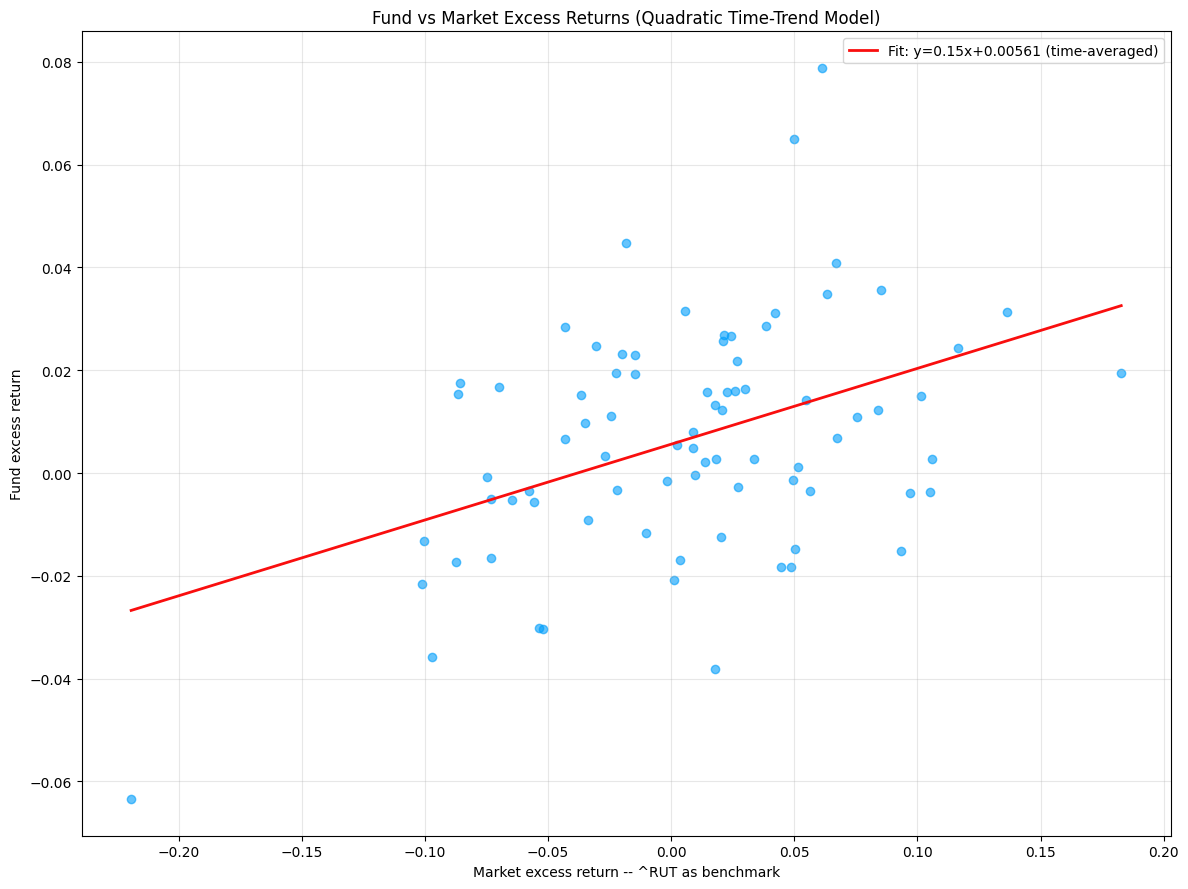

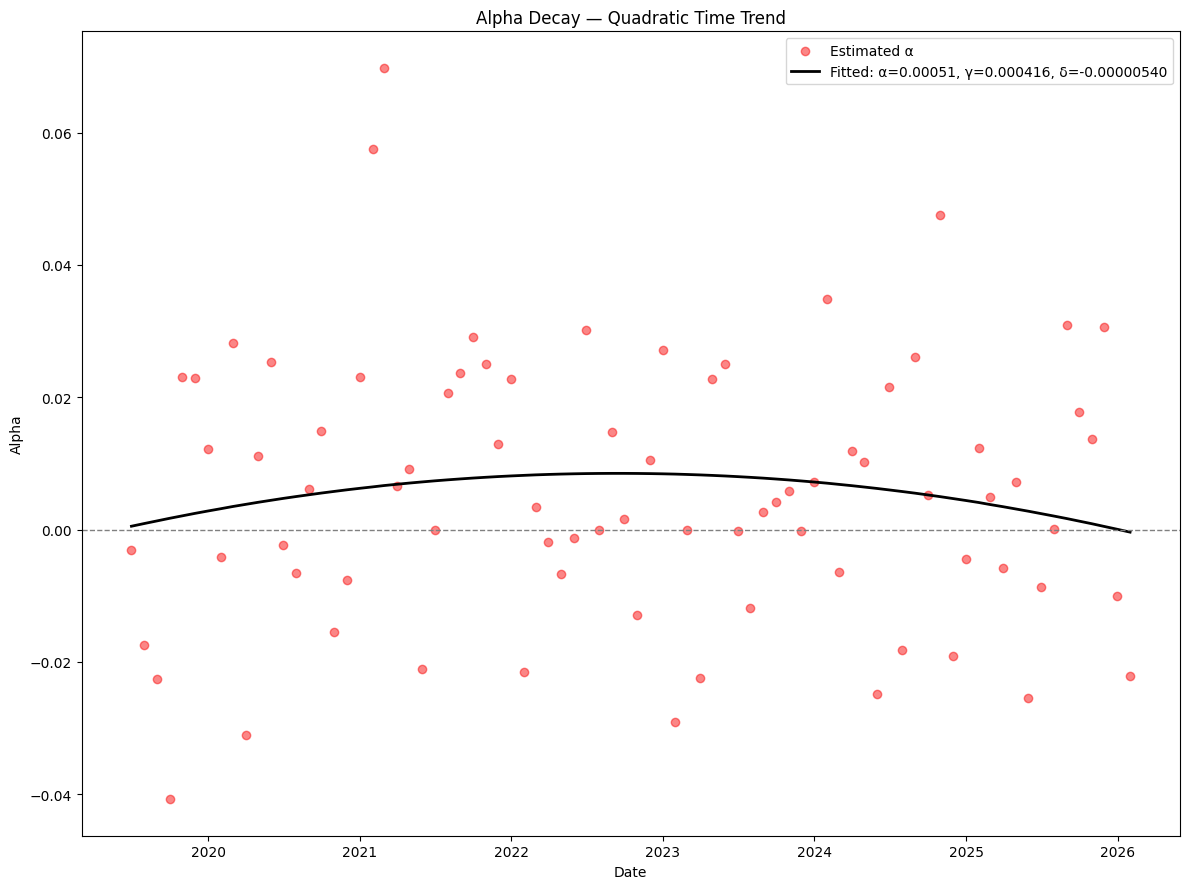

In [30]:
#CAPM regression but using a quadratic sequence

df['t'] = range(len(df))
df['t_sq'] = df['t'] ** 2

y = df['Fund Excess']
x = df[['Market Excess', 't', 't_sq']]
x = sm.add_constant(x)

results = sm.OLS(y, x).fit()
alpha = results.params['const']
beta  = results.params['Market Excess']
gamma = results.params['t']
delta = results.params['t_sq']

df['estimated_alpha'] = df['Fund Excess'] - beta * df['Market Excess']
fitted_alpha = alpha + gamma * df['t'] + delta * df['t_sq']

# Average intercept across time: alpha + gamma*mean(t) + delta*mean(t^2)
avg_intercept = alpha + gamma * df['t'].mean() + delta * df['t_sq'].mean()

x_sorted = x_mkt.sort_values()
y_fit = avg_intercept + beta * x_sorted

plt.figure(figsize=(12, 9))
plt.scatter(x_mkt, y_fund, alpha=0.6, color=beta_color)
plt.plot(
    x_sorted,
    y_fit,
    color=alpha_color,
    linewidth=2,
    label=f"Fit: y={beta:.2f}x+{avg_intercept:.5f} (time-averaged)",
)
plt.xlabel(f"Market excess return -- {ticker} as benchmark")
plt.ylabel("Fund excess return")
plt.title("Fund vs Market Excess Returns (Quadratic Time-Trend Model)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))
plt.scatter(df.index, df['estimated_alpha'], alpha=0.5, color=alpha_color, label="Estimated α")
plt.plot(df.index, fitted_alpha, color="#000000", linewidth=2,
         label=f"Fitted: α={alpha:.5f}, γ={gamma:.6f}, δ={delta:.8f}")
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.xlabel("Date")
plt.ylabel("Alpha")
plt.title("Alpha Decay — Quadratic Time Trend")
plt.legend()
plt.tight_layout()
plt.show()

# CAPM-style scatter (fund excess vs market excess) with Method #2 fitted line
x_mkt = df['Market Excess'].dropna()
y_fund = df['Fund Excess'].reindex(x_mkt.index).dropna()
x_mkt = x_mkt.reindex(y_fund.index)



In [31]:
p_alpha = results.pvalues['const']
p_beta  = results.pvalues['Market Excess']
p_gamma = results.pvalues['t']
p_delta = results.pvalues['t_sq']

print(f"α (intercept at t=0):   {alpha:.6f}   p={p_alpha:.5f}")
print(f"β (market exposure):    {beta:.6f}   p={p_beta:.5f}")
print(f"γ (linear time trend):  {gamma:.8f}   p={p_gamma:.5f}")
print(f"δ (quadratic time trend): {delta:.10f}   p={p_delta:.5f}")
print("-" * 60)

# Alpha significance
if p_alpha < 0.05:
    print(f"α is significant (p={p_alpha:.5f} < 0.05) — the fund has a non-zero intercept at inception.")
else:
    print(f"α is not significant (p={p_alpha:.5f}) — no evidence of initial alpha.")

# Beta significance
if p_beta < 0.05:
    print(f"β is significant (p={p_beta:.5f} < 0.05) — the fund has meaningful market exposure.")
else:
    print(f"β is not significant (p={p_beta:.5f}) — no significant market exposure detected.")

# Gamma significance (key decay parameter)
if p_gamma < 0.05 and gamma < 0:
    print(f"γ is significant and negative (p={p_gamma:.5f} < 0.05) — evidence of alpha decay over time.")
elif p_gamma < 0.05 and gamma > 0:
    print(f"γ is significant and positive (p={p_gamma:.5f} < 0.05) — evidence of alpha growth over time.")
else:
    print(f"γ is not significant (p={p_gamma:.5f}) — no evidence of a linear trend in alpha.")

# Delta significance
if p_delta < 0.05 and delta > 0:
    print(f"δ is significant and positive (p={p_delta:.5f} < 0.05) — the rate of alpha change is accelerating.")
elif p_delta < 0.05 and delta < 0:
    print(f"δ is significant and negative (p={p_delta:.5f} < 0.05) — the rate of alpha change is decelerating.")
else:
    print(f"δ is not significant (p={p_delta:.5f}) — no evidence of curvature in the alpha trend.")

α (intercept at t=0):   0.000505   p=0.94043
β (market exposure):    0.147530   p=0.00009
γ (linear time trend):  0.00041556   p=0.29423
δ (quadratic time trend): -0.0000054030   p=0.26566
------------------------------------------------------------
α is not significant (p=0.94043) — no evidence of initial alpha.
β is significant (p=0.00009 < 0.05) — the fund has meaningful market exposure.
γ is not significant (p=0.29423) — no evidence of a linear trend in alpha.
δ is not significant (p=0.26566) — no evidence of curvature in the alpha trend.


### Plotting cumulative returns, Sharpe, and rolling market volatility ###

C:\Users\admin\AppData\Local\Temp\ipykernel_16508\53906770.py:26: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  mkt_d = mkt_d.resample('M').apply(lambda x: (1 + x).prod() - 1)


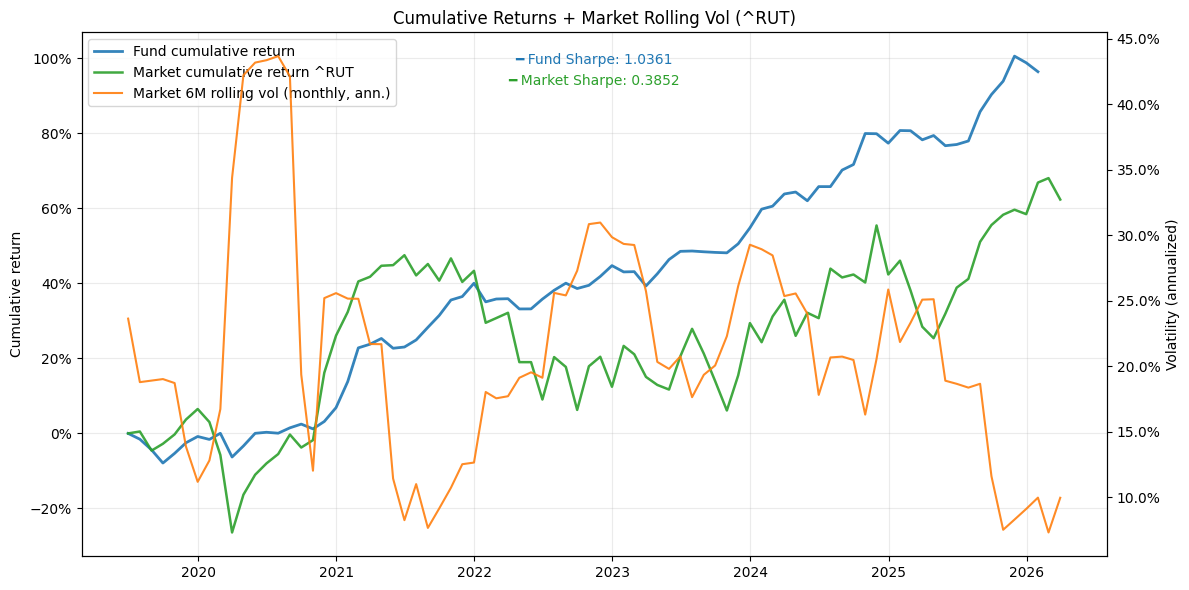

In [12]:
if monthly == True:
    #Sharpe and volatility -- monthly
    fund_excess_vol = df['Fund Excess'].std()
    fund_excess_vol_annualized = fund_excess_vol * np.sqrt(12)
    fund_sharpe_annualized = (df['Fund Excess'].mean() / fund_excess_vol) * np.sqrt(12)

    mkt_excess_vol = df['Market Excess'].std()
    mkt_excess_vol_annualized = mkt_excess_vol * np.sqrt(12)
    mkt_sharpe_annualized = (df['Market Excess'].mean() / mkt_excess_vol) * np.sqrt(12)

else:
    # Sharpe and volatility -- daily
    fund_excess_vol = df['Fund Excess'].std()
    fund_excess_vol_annualized = fund_excess_vol * np.sqrt(252)
    fund_sharpe_annualized = (df['Fund Excess'].mean() / fund_excess_vol) * np.sqrt(252)

    mkt_excess_vol = df['Market Excess'].std()
    mkt_excess_vol_annualized = mkt_excess_vol * np.sqrt(252)
    mkt_sharpe_annualized = (df['Market Excess'].mean() / mkt_excess_vol) * np.sqrt(252)

# --- Fund ---
fund_gross = (1 + fund_data["Return"].astype(float)).cumprod() #gross cumulative

if monthly == True:
    mkt_d = market_data["market_rets"].dropna().sort_index()
    mkt_d = mkt_d.resample('M').apply(lambda x: (1 + x).prod() - 1)
    mkt_d.index = mkt_d.index.to_period('M').to_timestamp('M')
else:
    mkt_d = market_data["market_rets"].astype(float).dropna().sort_index()

# Rolling vol (annualized) -- 6M window for monthly, 30-day window for daily
if monthly == True:
    mkt_vol1m_d = mkt_d.rolling(window=6).std() * np.sqrt(12)
else:
    mkt_vol1m_d = mkt_d.rolling(window=30).std() * np.sqrt(252)

# choose plot start where vol exists and fund exists
start = max(df.index.min(), mkt_vol1m_d.dropna().index.min())

# rebased fund cumulative return (starts at 0 at `start`)
fund_plot_gross = fund_gross.loc[fund_gross.index >= start]
fund_plot_cum = fund_plot_gross / fund_plot_gross.iloc[0] - 1

# rebased market cumulative return (starts at 0 at `start`)
mkt_cum_gross = (1 + mkt_d).cumprod()
base = mkt_cum_gross.loc[:start].iloc[-1]
mkt_cum_plot = mkt_cum_gross.loc[mkt_cum_gross.index >= start] / base - 1

mkt_vol_plot = mkt_vol1m_d.loc[mkt_vol1m_d.index >= start]

#Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

l1, = ax1.plot(
    fund_plot_cum.index, fund_plot_cum,
    color="tab:blue", lw=2, alpha=0.9,
    label="Fund cumulative return"
)
l2, = ax1.plot(
    mkt_cum_plot.index, mkt_cum_plot,
    color="tab:green", lw=1.8, alpha=0.9,
    label=f"Market cumulative return {ticker}"
)

ax1.set_ylabel("Cumulative return")
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
vol_label = "Market 6M rolling vol (monthly, ann.)" if monthly else "Market 1M rolling vol (daily, ann.)"
l3, = ax2.plot(
    mkt_vol_plot.index, mkt_vol_plot,
    color="tab:orange", lw=1.5, alpha=0.9,
    label=vol_label
)
ax2.set_ylabel("Volatility (annualized)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax1.set_title(f"Cumulative Returns + Market Rolling Vol ({ticker})")
ax1.legend(handles=[l1, l2, l3], loc="upper left")

ax1.text(
    0.5, 0.96,
    f"━ Fund Sharpe: {fund_sharpe_annualized:.4f}",
    transform=ax1.transAxes, ha="center", va="top", color=l1.get_color()
)
ax1.text(
    0.5, 0.92,
    f"━ Market Sharpe: {mkt_sharpe_annualized:.4f}",
    transform=ax1.transAxes, ha="center", va="top", color=l2.get_color()
)

plt.tight_layout()
plt.show()

### Analysing Kurtosis & Skewness ###

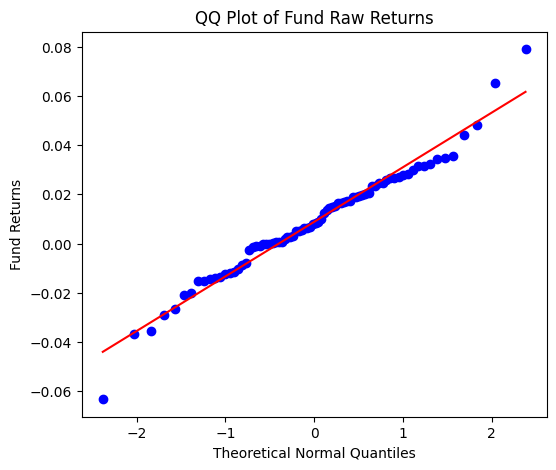

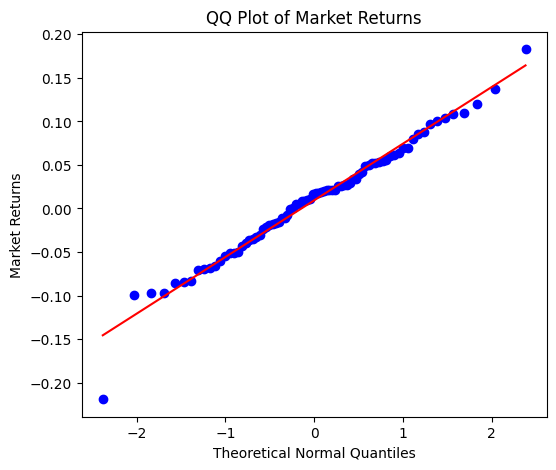

Kurtosis (Fund): 1.6572
Skewness (Fund):  -0.0407

Kurtosis (Market): 1.1797
Skewness (Market):  -0.2985


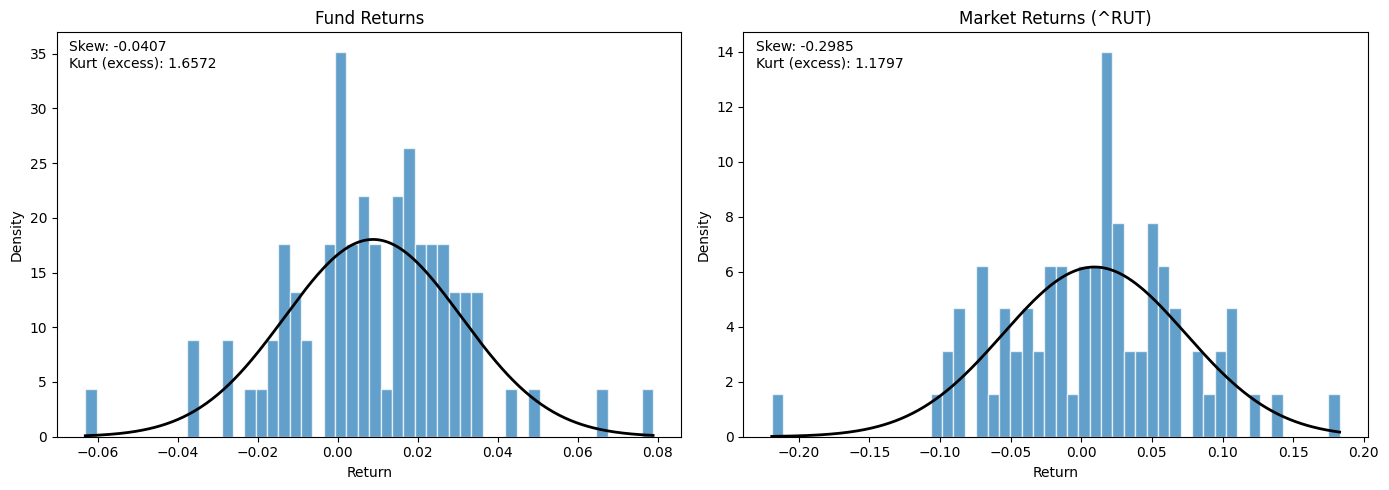

In [13]:
plt.figure(figsize=(6, 5))
stats.probplot(df['Return'], dist="norm", plot=plt)
plt.title("QQ Plot of Fund Raw Returns")
plt.ylabel("Fund Returns")
plt.xlabel("Theoretical Normal Quantiles")
plt.show()

plt.figure(figsize=(6, 5))
stats.probplot(df['Market Return'], dist="norm", plot=plt)
plt.title("QQ Plot of Market Returns")
plt.ylabel("Market Returns")
plt.xlabel("Theoretical Normal Quantiles")
plt.show()

mkt_kurtosis = df["Market Return"].kurtosis()
mkt_skew = df["Market Return"].skew()

fund_kurtosis = df['Return'].kurtosis()
fund_skew = df['Return'].skew()

print(f"Kurtosis (Fund): {fund_kurtosis:.4f}")
print(f"Skewness (Fund):  {fund_skew:.4f}")
print("")
print(f"Kurtosis (Market): {mkt_kurtosis:.4f}")
print(f"Skewness (Market):  {mkt_skew:.4f}")

def hist_with_stats(ax, s, title, xlabel):
    x = s.astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    mu, sigma = x.mean(), x.std(ddof=1)

    grid = np.linspace(x.min(), x.max(), 400)
    ax.hist(x, bins=50, density=True, alpha=0.7, edgecolor="white")
    ax.plot(grid, stats.norm.pdf(grid, mu, sigma), "k", linewidth=2)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.text(
        0.02, 0.98,
        f"Skew: {x.skew():.4f}\nKurt (excess): {x.kurtosis():.4f}",
        transform=ax.transAxes, va="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none", boxstyle="round,pad=0.3"),
    )

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
hist_with_stats(ax1, df['Return'], "Fund Returns", "Return")
hist_with_stats(ax2, df["Market Return"], f"Market Returns ({ticker})", "Return")
plt.tight_layout()
plt.show()
